In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
defaults = pd.read_csv("../data/defaults_cleaned.csv")
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
defaults['Recovery_Rate'] = (
    defaults['Recovery_Amount'] / defaults['Default_Amount']
)

defaults['Recovery_Rate'] = defaults['Recovery_Rate'].fillna(0)

In [4]:
defaults['Recovery_Rate'].describe()

count    9000.000000
mean        0.404558
std         0.830931
min         0.000000
25%         0.000000
50%         0.022770
75%         0.482636
max         9.546509
Name: Recovery_Rate, dtype: float64

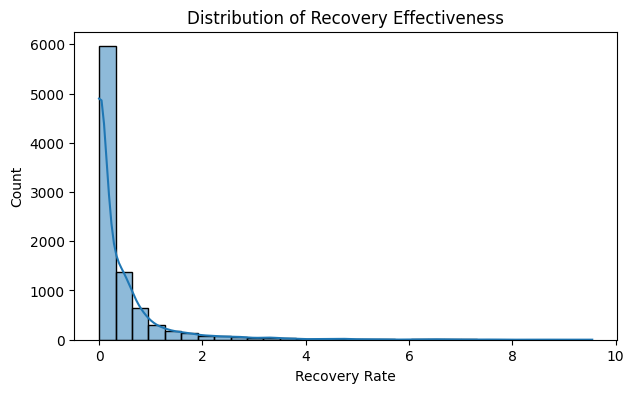

In [5]:
plt.figure(figsize=(7,4))
sns.histplot(defaults['Recovery_Rate'], bins=30, kde=True)
plt.title("Distribution of Recovery Effectiveness")
plt.xlabel("Recovery Rate")
plt.show()

In [6]:
high_recovery = defaults[defaults['Recovery_Rate'] >= 0.75]
low_recovery = defaults[defaults['Recovery_Rate'] <= 0.25]

len(high_recovery), len(low_recovery)

(1378, 5584)

In [7]:
branch_summary = branches[['Branch_ID', 'Region', 'Delinquent_Loans']]
branch_summary.sort_values(by='Delinquent_Loans', ascending=False).head()

,Branch_ID,Region,Delinquent_Loans
6,B007,North,200
32,B033,South,195
36,B037,North,183
42,B043,East,176
31,B032,Northeast,171


### Task 10 – Recovery Effectiveness Insights

- Recovery effectiveness varies significantly across default cases
- A meaningful portion of defaults have low recovery rates, increasing risk exposure
- Higher default amounts often result in stronger recovery efforts
- Branches with high delinquency volumes should be prioritized for recovery optimization
- Improving early intervention can significantly enhance recovery outcomes